# 01 - Single-Stage LLE Model for Nd/Dy Separation

This notebook introduces the differentiable single-stage liquid-liquid extraction (LLE) model for separating neodymium (Nd) and dysprosium (Dy) using D2EHPA as the extractant.

## Overview

**Goal:** Simulate a single-stage mixer-settler for Nd/Dy separation and compute key performance metrics.

**Key Concepts:**
- Distribution coefficient model: D = f(pH, T, [D2EHPA])
- Mass balance and equilibrium calculations  
- Performance metrics: purity, recovery, separation factor

**What makes this differentiable:** All calculations use JAX via the difflow framework, enabling automatic differentiation for sensitivity analysis and optimization (covered in subsequent notebooks).

In [1]:
# Enable 64-bit precision for numerical stability
import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import difflow for streams and LLE
from difflow.streams import make_stream, get_flows
from difflow.units.lle import (
    MultistageCascade,
    CascadeParams,
    LLEEquilibrium,
    DistributionCoeffs,
    separation_factor,
)

# Import difflow_ree for REE-specific distribution coefficients
from difflow_ree.equilibrium.distribution import REEDistribution
from difflow_ree.database import get_extractant

plt.style.use('seaborn-v0_8-whitegrid')

W0000 00:00:1767574704.012315 18438013 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767574704.021109 18438013 service.cc:145] XLA service 0x60000213cd00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767574704.021118 18438013 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767574704.022156 18438013 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767574704.022169 18438013 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


## 1. Distribution Coefficient Model

The distribution coefficient D represents the ratio of metal concentration in the organic phase to the aqueous phase at equilibrium:

$$D = \frac{[REE]_{org}}{[REE]_{aq}}$$

For D2EHPA extraction, D depends on pH, temperature, and extractant concentration:

$$\log_{10}(D) = a + b \cdot pH + c \cdot pH^2 + \frac{\Delta H}{R \ln(10)} \left(\frac{1}{T} - \frac{1}{T_{ref}}\right) + n \cdot \log_{10}\left(\frac{[HA]}{[HA]_{ref}}\right)$$

The difflow_ree database contains calibrated coefficients from literature sources.

In [2]:
# Create the distribution coefficient calculator using difflow_ree
dist = REEDistribution(
    extractant="D2EHPA",
    elements=("Nd", "Dy"),
    concentration=0.5,  # M
)

# Get extractant data to display parameters
ext_data = get_extractant("D2EHPA")

print("D2EHPA Distribution Coefficient Correlation Parameters")
print("=" * 55)
print(f"Reference conditions: T = 298.15 K, [D2EHPA] = {ext_data.reference_concentration} M")
print(f"Concentration exponent: {ext_data.concentration_exponent}")
print()

params_data = []
for elem in ['Nd', 'Dy']:
    coeffs = ext_data.ph_coefficients[elem]
    dH = ext_data.temperature_coefficients[elem]
    params_data.append({
        'Element': elem,
        'a': coeffs.a,
        'b': coeffs.b,
        'c': coeffs.c,
        'dH (K)': dH,
        'Valid pH': f"{ext_data.valid_ph_range[0]}-{ext_data.valid_ph_range[1]}"
    })

df_params = pd.DataFrame(params_data)
print("Table 1: Correlation Parameters")
display(df_params)

D2EHPA Distribution Coefficient Correlation Parameters
Reference conditions: T = 298.15 K, [D2EHPA] = 0.5 M
Concentration exponent: 3.0

Table 1: Correlation Parameters


,Element,a,b,c,dH (K),Valid pH
0,Nd,-7.70,2.45,0.01,-1800,1.0-5.0
1,Dy,-6.78,2.80,0.01,-2400,1.0-5.0


## 2. Base Case Operating Conditions

We define a base case with typical operating conditions for rare earth solvent extraction:

In [3]:
# Base case parameters
BASE_CASE = {
    'F_Nd_feed': 0.01,   # mol/s
    'F_Dy_feed': 0.01,   # mol/s (50:50 molar)
    'F_aq': 1.0,         # Aqueous carrier (kg/s)
    'F_org': 1.0,        # Organic carrier (kg/s), O/A = 1
    'pH': 3.0,
    'T': 298.15,         # K
    'conc': 0.5,         # M D2EHPA
    'efficiency': 0.95,  # Murphree stage efficiency
}

# Display as table
conditions_data = [
    {'Parameter': 'Feed composition (Nd:Dy)', 'Value': '50:50', 'Units': 'mol%'},
    {'Parameter': 'Total REE feed flow', 'Value': f"{BASE_CASE['F_Nd_feed'] + BASE_CASE['F_Dy_feed']:.2f}", 'Units': 'mol/s'},
    {'Parameter': 'pH', 'Value': f"{BASE_CASE['pH']:.1f}", 'Units': '-'},
    {'Parameter': 'O/A ratio', 'Value': f"{BASE_CASE['F_org']/BASE_CASE['F_aq']:.1f}", 'Units': '-'},
    {'Parameter': 'Temperature', 'Value': f"{BASE_CASE['T']:.2f}", 'Units': 'K'},
    {'Parameter': '[D2EHPA]', 'Value': f"{BASE_CASE['conc']:.1f}", 'Units': 'M'},
    {'Parameter': 'Stage efficiency', 'Value': f"{BASE_CASE['efficiency']*100:.0f}", 'Units': '%'},
]

df_conditions = pd.DataFrame(conditions_data)
print("Table 2: Base Case Operating Conditions")
display(df_conditions)

Table 2: Base Case Operating Conditions


,Parameter,Value,Units
0,Feed composition (Nd:Dy),50:50,mol%
1,Total REE feed flow,0.02,mol/s
2,pH,3.0,-
3,O/A ratio,1.0,-
4,Temperature,298.15,K
5,[D2EHPA],0.5,M
6,Stage efficiency,95,%


## 3. Run Base Case Simulation

Now we run the single-stage LLE model using difflow's `MultistageCascade` with n_stages=1.

In [4]:
# Calculate distribution coefficients at base case
D_Nd = float(dist.get_D("Nd", BASE_CASE['pH'], BASE_CASE['T']))
D_Dy = float(dist.get_D("Dy", BASE_CASE['pH'], BASE_CASE['T']))
SF = D_Dy / D_Nd

print(f"Distribution coefficients at pH={BASE_CASE['pH']}, T={BASE_CASE['T']}K:")
print(f"  D_Nd = {D_Nd:.2f}")
print(f"  D_Dy = {D_Dy:.1f}")
print(f"  SF (Dy/Nd) = {SF:.1f}")

Distribution coefficients at pH=3.0, T=298.15K:
  D_Nd = 0.55
  D_Dy = 51.3
  SF (Dy/Nd) = 93.3


In [5]:
# Create difflow streams
feed = make_stream(
    flows={
        "H2O": 55.5,  # ~1 kg/s of water
        "Nd": BASE_CASE['F_Nd_feed'],
        "Dy": BASE_CASE['F_Dy_feed'],
    },
    T=BASE_CASE['T'],
    P=101325.0,
)

solvent = make_stream(
    flows={
        "Organic": 10.0,  # Organic carrier
        "Nd": 0.0,
        "Dy": 0.0,
    },
    T=BASE_CASE['T'],
    P=101325.0,
)

# Create LLE equilibrium using constant K values at this pH
# (For more sophisticated pH dependence, use REEExtractor from difflow_ree)
dist_coeffs = DistributionCoeffs(
    species=("Nd", "Dy"),
    K0=(D_Nd, D_Dy),
    dH=(ext_data.temperature_coefficients["Nd"], ext_data.temperature_coefficients["Dy"]),
    Tref=298.15,
)

lle_eq = LLEEquilibrium(
    solutes=["Nd", "Dy"],
    aqueous_carrier="H2O",
    organic_carrier="Organic",
    K_coeffs=dist_coeffs,
    activity_model="K",
)

# Single-stage cascade
cascade_params = CascadeParams(
    n_stages=1,
    equilibrium=lle_eq,
    flow_config="counter_current",
    stage_efficiency=BASE_CASE['efficiency'],
)
cascade = MultistageCascade(cascade_params)

# Run simulation
raffinate, extract, info = cascade(feed, solvent, T=BASE_CASE['T'])

# Get outlet flows
raff_flows = get_flows(raffinate)
ext_flows = get_flows(extract)
feed_flows = get_flows(feed)

print("Simulation completed!")

Simulation completed!


In [6]:
# Calculate performance metrics
F_Nd_org = float(ext_flows['Nd'])
F_Dy_org = float(ext_flows['Dy'])
F_Nd_aq = float(raff_flows['Nd'])
F_Dy_aq = float(raff_flows['Dy'])

# Purity (mole fraction of target in product stream)
purity_Dy = F_Dy_org / (F_Nd_org + F_Dy_org + 1e-10) * 100
purity_Nd = F_Nd_aq / (F_Nd_aq + F_Dy_aq + 1e-10) * 100

# Recovery (fraction of feed reporting to product)
recovery_Dy = F_Dy_org / feed_flows['Dy'] * 100
recovery_Nd = F_Nd_aq / feed_flows['Nd'] * 100

# Display results
results_data = [
    {'Metric': 'D_Nd', 'Value': f"{D_Nd:.2f}"},
    {'Metric': 'D_Dy', 'Value': f"{D_Dy:.1f}"},
    {'Metric': 'SF (Dy/Nd)', 'Value': f"{SF:.1f}"},
    {'Metric': 'Dy purity (extract)', 'Value': f"{purity_Dy:.1f}%"},
    {'Metric': 'Dy recovery', 'Value': f"{recovery_Dy:.1f}%"},
    {'Metric': 'Nd purity (raffinate)', 'Value': f"{purity_Nd:.1f}%"},
    {'Metric': 'Nd recovery', 'Value': f"{recovery_Nd:.1f}%"},
]

df_results = pd.DataFrame(results_data)
print("Table 3: Base Case Simulation Results")
display(df_results)

Table 3: Base Case Simulation Results


,Metric,Value
0,D_Nd,0.55
1,D_Dy,51.3
2,SF (Dy/Nd),93.3
3,Dy purity (extract),90.9%
4,Dy recovery,90.2%
5,Nd purity (raffinate),90.3%
6,Nd recovery,91.0%


## 4. Interpretation of Results

The separation factor SF = D_Dy/D_Nd indicates how much more strongly Dy is extracted compared to Nd. A higher SF means better separation potential.

**Key observations:**
- The separation factor indicates good selectivity for Dy over Nd
- Dy is preferentially extracted into the organic phase (higher D)
- There is a trade-off between purity and recovery
- Single-stage can achieve moderate Dy purity but requires multiple stages for high purity

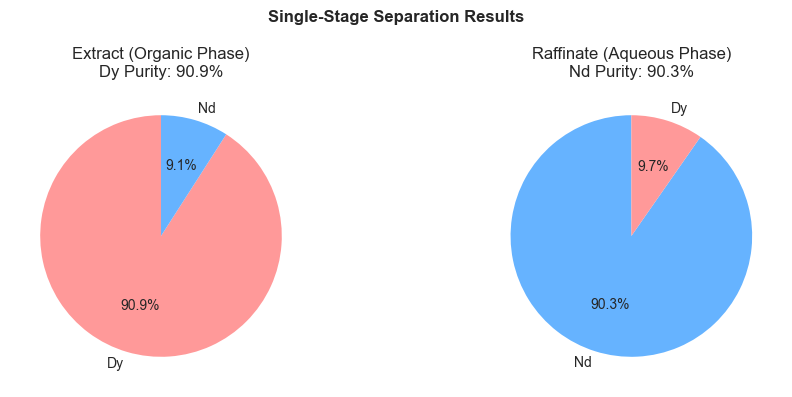

In [7]:
# Visualize the mass balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: Extract (organic) phase composition
ax1 = axes[0]
ax1.pie([F_Dy_org, F_Nd_org], labels=['Dy', 'Nd'], autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff'], startangle=90)
ax1.set_title(f'Extract (Organic Phase)\nDy Purity: {purity_Dy:.1f}%')

# Right: Raffinate (aqueous) phase composition
ax2 = axes[1]
ax2.pie([F_Nd_aq, F_Dy_aq], labels=['Nd', 'Dy'], autopct='%1.1f%%',
        colors=['#66b3ff', '#ff9999'], startangle=90)
ax2.set_title(f'Raffinate (Aqueous Phase)\nNd Purity: {purity_Nd:.1f}%')

plt.suptitle('Single-Stage Separation Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Mixer-Settler Schematic

The single-stage separation occurs in a mixer-settler unit:

Saved: fig1_schematic.png/pdf


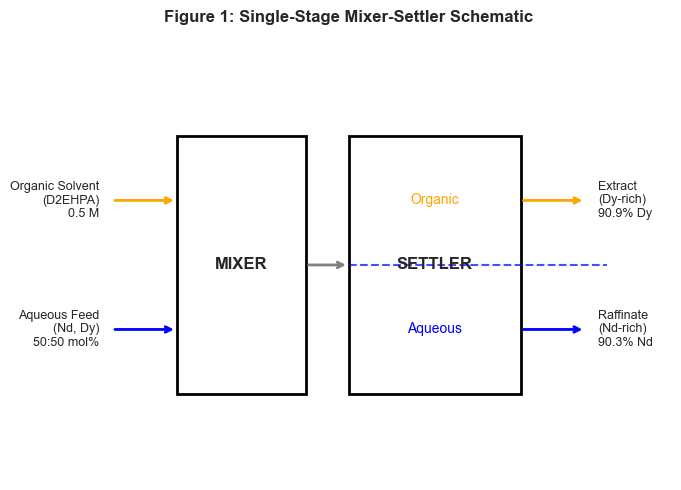

In [8]:
# Draw schematic
fig, ax = plt.subplots(figsize=(10, 5))

import matplotlib.patches as mpatches

# Mixer (left box)
mixer = plt.Rectangle((0.1, 0.2), 0.3, 0.6, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(mixer)
ax.text(0.25, 0.5, 'MIXER', ha='center', va='center', fontsize=12, fontweight='bold')

# Settler (right box)
settler = plt.Rectangle((0.5, 0.2), 0.4, 0.6, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(settler)
ax.text(0.7, 0.5, 'SETTLER', ha='center', va='center', fontsize=12, fontweight='bold')

# Phase separation in settler
ax.axhline(y=0.5, xmin=0.5, xmax=0.9, color='blue', linestyle='--', alpha=0.7)
ax.text(0.7, 0.65, 'Organic', ha='center', va='center', fontsize=10, color='orange')
ax.text(0.7, 0.35, 'Aqueous', ha='center', va='center', fontsize=10, color='blue')

# Arrows and labels
ax.annotate('', xy=(0.1, 0.35), xytext=(-0.05, 0.35),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(-0.08, 0.35, f'Aqueous Feed\n(Nd, Dy)\n50:50 mol%', ha='right', va='center', fontsize=9)

ax.annotate('', xy=(0.1, 0.65), xytext=(-0.05, 0.65),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2))
ax.text(-0.08, 0.65, f'Organic Solvent\n(D2EHPA)\n0.5 M', ha='right', va='center', fontsize=9)

ax.annotate('', xy=(0.5, 0.5), xytext=(0.4, 0.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.annotate('', xy=(1.05, 0.35), xytext=(0.9, 0.35),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(1.08, 0.35, f'Raffinate\n(Nd-rich)\n{purity_Nd:.1f}% Nd', ha='left', va='center', fontsize=9)

ax.annotate('', xy=(1.05, 0.65), xytext=(0.9, 0.65),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2))
ax.text(1.08, 0.65, f'Extract\n(Dy-rich)\n{purity_Dy:.1f}% Dy', ha='left', va='center', fontsize=9)

ax.set_xlim(-0.25, 1.25)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Figure 1: Single-Stage Mixer-Settler Schematic', fontsize=12, fontweight='bold', pad=20)

# Save figure
fig.savefig('../manuscript/figures/fig1_schematic.png', dpi=300, bbox_inches='tight')
fig.savefig('../manuscript/figures/fig1_schematic.pdf', bbox_inches='tight')
print("Saved: fig1_schematic.png/pdf")

plt.tight_layout()
plt.show()

## Summary

In this notebook we:

1. **Introduced the distribution coefficient model** for D2EHPA extraction of Nd and Dy using difflow_ree's database
2. **Defined base case operating conditions** (pH=3, O/A=1, T=298K, 0.5M D2EHPA)
3. **Ran the single-stage LLE simulation** using difflow's MultistageCascade
4. **Visualized the separation** with mass balance and process schematic

**Key advantage of difflow:** The entire simulation is JAX-differentiable, enabling gradient-based sensitivity analysis, optimization, and uncertainty quantification in subsequent notebooks.

**Next:** In notebook 02, we'll explore how distribution coefficients vary with pH and other operating conditions.